In [2]:
%load_ext autoreload
%autoreload 2

# PatchCore — features pré-entraînées (alternative à l'auto-encodeur)

Suite de [tp_deep_learning.ipynb](tp_deep_learning.ipynb) (voir aussi le
[rapport](tp_deep_learning_report.md)) : au lieu d'apprendre à **reconstruire** les images, on compare les
features d'un CNN **pré-entraîné** (gelé, non ré-entraîné sur nos données) à une mémoire de patchs saines.
Le score d'anomalie d'un patch = distance à son plus proche voisin dans cette mémoire ; le score d'une
image = le pire de ses patchs.

## Chargement des données

**Pas** les `.bin.gz` de la partie 2 (ceux-ci passent par le pipeline 128×128 de l'auto-encodeur — un
double redimensionnement 1024→128→224 qui détruirait du détail fin dès la première étape, alors que
PatchCore n'a aucune contrainte de taille fixe). On recharge directement les PNG originaux et on
redimensionne **une seule fois**, 1024 → 224.

In [3]:
import cv2
from pathlib import Path

import numpy as np

DATA_DIR = Path('screw')
BACKBONE_SIZE = 224
SEED = 42

TRAIN_GOOD_DIR = DATA_DIR / 'train' / 'good'
TEST_DIR = DATA_DIR / 'test'
defect_types = sorted(p.name for p in TEST_DIR.iterdir() if p.is_dir() and p.name != 'good')


def load_image(path, size=BACKBONE_SIZE):
    """Charge en niveaux de gris et redimensionne directement à la taille du backbone (1024 -> 224)."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img.astype('float32')[..., np.newaxis] / 255.0


def load_folder(folder, size=BACKBONE_SIZE):
    paths = sorted(Path(folder).glob('*.png'))
    return np.stack([load_image(p, size) for p in paths])


X_train_norm = load_folder(TRAIN_GOOD_DIR)
test_good_norm = load_folder(TEST_DIR / 'good')

# Concatène les défauts dans l'ordre des catégories (triées) puis des fichiers (triés) — et garde la
# catégorie de chaque indice au passage, pour la répartition des faux négatifs plus bas.
test_defects_norm_stacked = []
defect_category_per_index = []
for defect in defect_types:
    imgs = load_folder(TEST_DIR / defect)
    test_defects_norm_stacked.append(imgs)
    defect_category_per_index += [defect] * len(imgs)
test_defects_norm_stacked = np.concatenate(test_defects_norm_stacked)

print('Train (normé)  :', X_train_norm.shape, X_train_norm.dtype)
print('Test saines    :', test_good_norm.shape)
print('Test défauts   :', test_defects_norm_stacked.shape)

Train (normé)  : (320, 224, 224, 1) float32
Test saines    : (41, 224, 224, 1)
Test défauts   : (119, 224, 224, 1)


## Extraction de features

`ResNet50` pré-entraîné sur ImageNet, tronqué à une couche intermédiaire (`conv4_block6_out`, stride 16 →
grille 14×14, plus grossière que `conv3_block4_out`/28×28 utilisé initialement). Nos images sont en
niveaux de gris (224×224×1) : on les convertit en RGB avant de les passer dans le backbone (gelé — pas
d'entraînement).

In [4]:
import tensorflow as tf
from tensorflow import keras

LAYER_NAME = 'conv4_block6_out'  # stride 16 -> grille 14x14 pour une entrée 224x224

backbone = keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(BACKBONE_SIZE, BACKBONE_SIZE, 3)
)
feature_extractor = keras.Model(backbone.input, backbone.get_layer(LAYER_NAME).output)
feature_extractor.trainable = False


def extract_patch_features(images, batch_size=32):
    """images (N, H, W, 1) dans [0, 1] -> features patch (N, h, w, C)."""
    rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(images))
    rgb = tf.image.resize(rgb, (BACKBONE_SIZE, BACKBONE_SIZE))
    rgb = keras.applications.resnet50.preprocess_input(rgb * 255.0)
    return feature_extractor.predict(rgb, batch_size=batch_size, verbose=0)


sample = extract_patch_features(X_train_norm[:1])
print('Grille de patchs :', sample.shape[1:3], '| dimension des features :', sample.shape[-1])

Grille de patchs : (14, 14) | dimension des features : 1024


## Mémoire de patchs saines

On extrait les features de **toutes** les images saines d'entraînement, on aplatit en patchs. `MEMORY_SIZE`
plafonne un éventuel sous-échantillonnage — ici fixé au-delà du nombre total de patchs (62 720), donc
**mémoire complète, sans sous-échantillonnage**.

*Constat empirique* : avec seulement 4-16% des patchs en mémoire (testé plus haut dans l'historique), l'AUROC
plafonnait à ~0.75 — beaucoup de patchs saines de test n'avaient simplement aucun voisin proche dans une
mémoire trop clairsemée, ce qui gonflait leur score sans lien avec un vrai défaut. Avec la mémoire complète,
**AUROC 0.923** (contre 0.754 à 16% de couverture) : la couverture de la mémoire était bien le facteur
limitant principal, pas la résolution spatiale des patchs ni les features en elles-mêmes.

In [5]:
MEMORY_SIZE = 70_000

train_features = extract_patch_features(X_train_norm)
n, h, w, c = train_features.shape
memory_bank_full = train_features.reshape(-1, c)

rng = np.random.default_rng(SEED)
subset_idx = rng.choice(len(memory_bank_full), size=min(MEMORY_SIZE, len(memory_bank_full)), replace=False)
memory_bank = memory_bank_full[subset_idx]

print(f'Mémoire : {memory_bank.shape} (sous-échantillonnée depuis {memory_bank_full.shape[0]} patchs)')

Mémoire : (62720, 1024) (sous-échantillonnée depuis 62720 patchs)


## Score d'anomalie (plus proche voisin)

Pour chaque patch d'une image de test, on cherche son plus proche voisin dans la mémoire de patchs saines.
Le score de l'image = la **pire** distance parmi ses patchs (un seul patch anormal suffit à signaler
l'image, contrairement à une moyenne qui dilue le signal — même logique que le centile 99 côté
auto-encodeur).

In [6]:
from sklearn.neighbors import NearestNeighbors

nearest_neighbor = NearestNeighbors(n_neighbors=1).fit(memory_bank)


def anomaly_score(images):
    """Retourne le score par image (max des distances patch) et la carte de distances par patch."""
    features = extract_patch_features(images)
    n, h, w, c = features.shape
    flat = features.reshape(-1, c)
    distances, _ = nearest_neighbor.kneighbors(flat)
    distance_maps = distances.reshape(n, h, w)
    return distance_maps.max(axis=(1, 2)), distance_maps

In [7]:
errors_test_good, _ = anomaly_score(test_good_norm)
errors_test_defects, _ = anomaly_score(test_defects_norm_stacked)

print('Score (saines, test)  :', errors_test_good.shape)
print(f'  moyenne = {errors_test_good.mean():.3f}, écart-type = {errors_test_good.std():.3f}')
print('Score (défauts, test) :', errors_test_defects.shape)
print(f'  moyenne = {errors_test_defects.mean():.3f}, écart-type = {errors_test_defects.std():.3f}')

Score (saines, test)  : (41,)
  moyenne = 18.996, écart-type = 2.040
Score (défauts, test) : (119,)
  moyenne = 25.002, écart-type = 4.012


## Distribution des scores

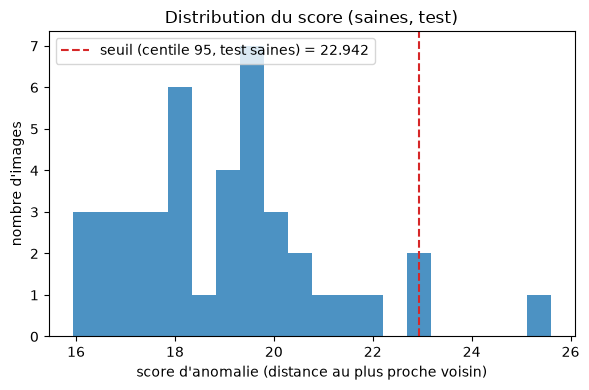

In [8]:
import matplotlib.pyplot as plt

threshold_p95 = np.percentile(errors_test_good, 95)

plt.figure(figsize=(6, 4))
plt.hist(errors_test_good, bins=20, color='tab:blue', alpha=0.8)
plt.axvline(threshold_p95, color='tab:red', linestyle='--', label=f'seuil (centile 95, test saines) = {threshold_p95:.3f}')
plt.xlabel('score d\'anomalie (distance au plus proche voisin)')
plt.ylabel("nombre d'images")
plt.title('Distribution du score (saines, test)')
plt.legend()
plt.tight_layout()
plt.show()

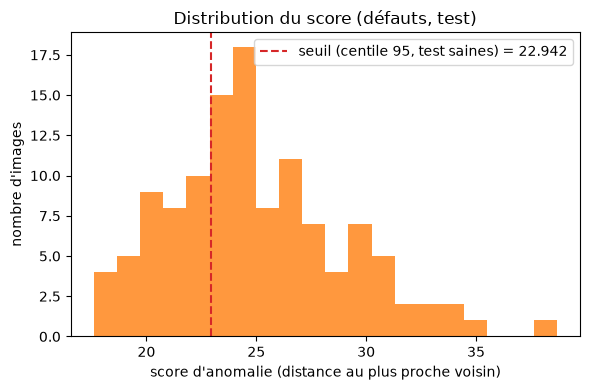

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(errors_test_defects, bins=20, color='tab:orange', alpha=0.8)
plt.axvline(threshold_p95, color='tab:red', linestyle='--', label=f'seuil (centile 95, test saines) = {threshold_p95:.3f}')
plt.xlabel('score d\'anomalie (distance au plus proche voisin)')
plt.ylabel("nombre d'images")
plt.title('Distribution du score (défauts, test)')
plt.legend()
plt.tight_layout()
plt.show()

## ROC & matrice de confusion

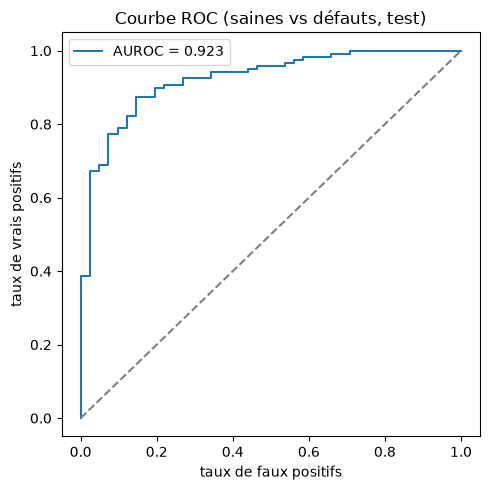

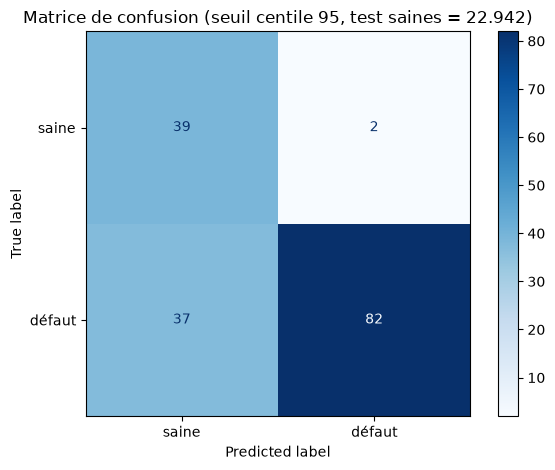

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, auc, confusion_matrix, roc_curve

y_true = np.concatenate([np.zeros(len(errors_test_good)), np.ones(len(errors_test_defects))])
y_score = np.concatenate([errors_test_good, errors_test_defects])

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'AUROC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('taux de faux positifs')
plt.ylabel('taux de vrais positifs')
plt.title('Courbe ROC (saines vs défauts, test)')
plt.legend()
plt.tight_layout()
plt.show()

y_pred = (y_score > threshold_p95).astype(int)
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['saine', 'défaut']).plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil centile 95, test saines = {threshold_p95:.3f})')
plt.tight_layout()
plt.show()

## Quel défaut est loupé ?

manipulated_front   : 9 loupé(s)
scratch_head        : 6 loupé(s)
scratch_neck        : 1 loupé(s)
thread_side         : 15 loupé(s)
thread_top          : 6 loupé(s)


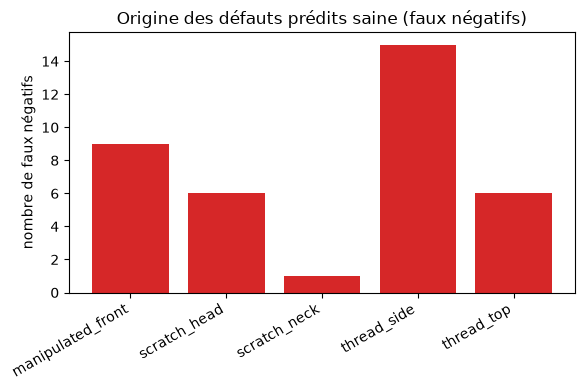

In [11]:
from collections import Counter

n_good = len(errors_test_good)
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0] - n_good  # défaut → saine

missed_defect_types = [defect_category_per_index[i] for i in fn_idx]
counts = Counter(missed_defect_types)

for defect in defect_types:
    print(f'{defect:<20}: {counts.get(defect, 0)} loupé(s)')

plt.figure(figsize=(6, 4))
plt.bar(defect_types, [counts.get(d, 0) for d in defect_types], color='tab:red')
plt.ylabel('nombre de faux négatifs')
plt.title('Origine des défauts prédits saine (faux négatifs)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()